In [1]:
import sys
from pathlib import Path
import pandas as pd
project_root = Path().resolve().parent
data_path = project_root / "data"
orders = pd.read_csv(data_path/"olist_orders_dataset.csv")
customers = pd.read_csv(data_path/"olist_customers_dataset.csv")



In [ ]:
# combine data
df = orders.merge(customers, on = "customer_id", how = "left")

In [4]:
# clean data and create delay
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])


df["delay_days"] = (
df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

df["is_delayed"] = df["delay_days"] > 0

In [6]:
# Segment by state
state_kpi = df.groupby("customer_state").agg(
total_orders=("order_id", "count"),
delayed_orders=("is_delayed", "sum")
).reset_index()

state_kpi["delay_rate"] = state_kpi["delayed_orders"] / state_kpi["total_orders"]

print(state_kpi.sort_values("delay_rate", ascending=False))

   customer_state  total_orders  delayed_orders  delay_rate
1              AL           413              85    0.205811
9              MA           747             125    0.167336
24             SE           350              51    0.145714
16             PI           495              66    0.133333
5              CE          1336             176    0.131737
4              BA          3380             396    0.117160
18             RJ         12852            1495    0.116324
13             PA           975             106    0.108718
21             RR            46               5    0.108696
7              ES          2033             214    0.105263
14             PB           536              54    0.100746
26             TO           280              27    0.096429
11             MS           715              68    0.095105
15             PE          1652             153    0.092615
19             RN           485              44    0.090722
23             SC          3637         

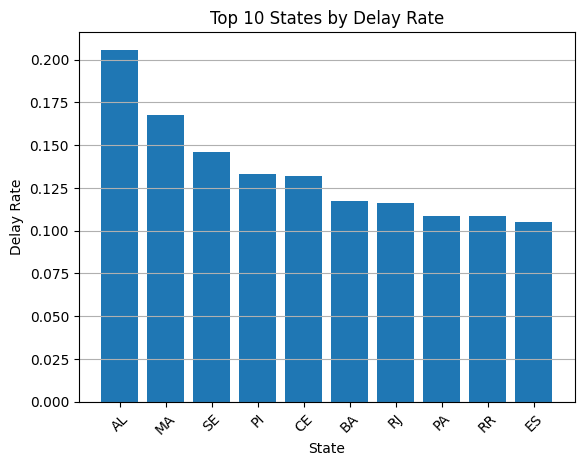

In [11]:
state_kpi = state_kpi.sort_values("delay_rate", ascending=False)

top_states = state_kpi.head(10)

import matplotlib.pyplot as plt
plt.figure()

plt.bar(top_states["customer_state"], top_states["delay_rate"])

plt.title("Top 10 States by Delay Rate")
plt.xlabel("State")
plt.ylabel("Delay Rate")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

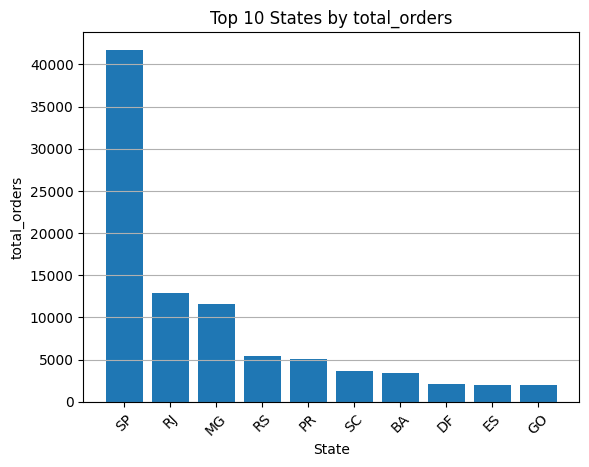

In [12]:
state_kpi = state_kpi.sort_values("total_orders", ascending=False)

top_states = state_kpi.head(10)

import matplotlib.pyplot as plt
plt.figure()

plt.bar(top_states["customer_state"], top_states["total_orders"])

plt.title("Top 10 States by total_orders")
plt.xlabel("State")
plt.ylabel("total_orders")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

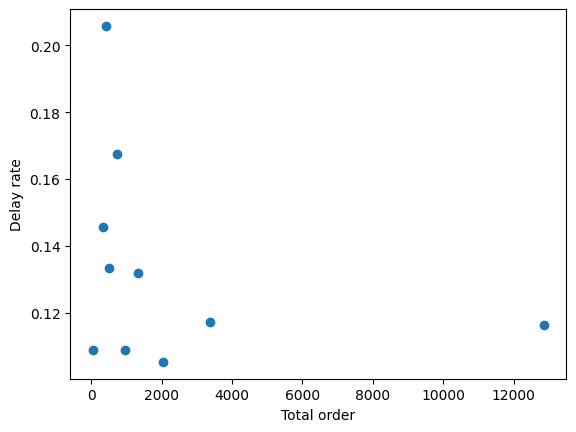

In [13]:
state_kpi = state_kpi.sort_values(["delay_rate", "total_orders"], ascending=[False, False]).head(10)
plt.scatter(state_kpi["total_orders"], state_kpi["delay_rate"])
plt.xlabel("Total order")
plt.ylabel("Delay rate")
plt.show